In [2]:
import os
import gc
import random

import h5py
import dice_ml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from scipy.stats import ttest_ind

from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
)

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    Embedding,
    Layer,
    Add,
    Flatten,
)
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.losses import CategoricalFocalCrossentropy
from tensorflow.keras.metrics import (
    CategoricalAccuracy,
    Precision,
    Recall,
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K


# Suppress TensorFlow warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Reset random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [13]:
# Load training dataset
train_data = pd.read_csv(
    "datasets/CICIDS2017/train_test/CICIDS2017_Train_80.csv"
)

# Load testing dataset
test_data = pd.read_csv(
    "datasets/CICIDS2017/train_test/CICIDS2017_Test_20.csv"
)

# Features
X_train = train_data.drop("label", axis=1).values
X_test = test_data.drop("label", axis=1).values

# Labels
y_train = train_data["label"].values
y_test = test_data["label"].values

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (1948553, 40)
Test : (487139, 40)


In [14]:
# =========================
# Dataset Sanity Checks
# =========================

print("Train shape:", train_data.shape)
print("Test shape :", test_data.shape)

# Check columns
print("\nNumber of columns:")
print("Train:", len(train_data.columns))
print("Test :", len(test_data.columns))

# Check if label column exists exactly once
print("\nLabel column exists:")
print("Train:", "label" in train_data.columns)
print("Test :", "label" in test_data.columns)

# Check duplicate column names
duplicate_cols = train_data.columns[train_data.columns.duplicated()]
print("\nDuplicate columns:", list(duplicate_cols))

# Missing values
print("\nMissing values:")
print("Train:", train_data.isnull().sum().sum())
print("Test :", test_data.isnull().sum().sum())

# Infinite values
print("\nInfinite values:")
print("Train:", np.isinf(X_train).sum())
print("Test :", np.isinf(X_test).sum())

# Feature dimensions
print("\nFeature shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# Labels
print("\nLabel shapes:")
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# Class distribution
print("\nTraining label distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting label distribution:")
print(pd.Series(y_test).value_counts().sort_index())

# Feature data types
print("\nFeature dtypes:")
print(train_data.drop(columns="label").dtypes.value_counts())

# Check whether all features are numeric
non_numeric = train_data.drop(columns="label").select_dtypes(exclude=[np.number]).columns
print("\nNon-numeric feature columns:", list(non_numeric))

# Ensure train and test have identical feature columns
same_columns = train_data.drop(columns="label").columns.equals(
    test_data.drop(columns="label").columns
)
print("\nTrain/Test feature columns match:", same_columns)

Train shape: (1948553, 41)
Test shape : (487139, 41)

Number of columns:
Train: 41
Test : 41

Label column exists:
Train: True
Test : True

Duplicate columns: []

Missing values:
Train: 0
Test : 0

Infinite values:
Train: 0
Test : 0

Feature shapes:
X_train: (1948553, 40)
X_test : (487139, 40)

Label shapes:
y_train: (1948553,)
y_test : (487139,)

Training label distribution:
0     1428580
1        4406
2       76586
3        6691
4      277915
5        5488
6        4142
7        7625
8          10
9      129058
10       4759
11       2187
12         19
13       1087
Name: count, dtype: int64

Testing label distribution:
0     357145
1       1102
2      19147
3       1673
4      69479
5       1372
6       1035
7       1906
8          2
9      32265
10      1190
11       547
12         5
13       271
Name: count, dtype: int64

Feature dtypes:
float64    40
Name: count, dtype: int64

Non-numeric feature columns: []

Train/Test feature columns match: True


In [15]:
num_classes = len(np.unique(y_train))

print("Classes:", num_classes)

y_train_cat = to_categorical(
    y_train,
    num_classes=num_classes
)

y_test_cat = to_categorical(
    y_test,
    num_classes=num_classes
)

print(y_train_cat.shape)
print(y_test_cat.shape)

Classes: 14
(1948553, 14)
(487139, 14)


In [16]:


# ============================================================
# Hyperparameters
# ============================================================

NUM_FEATURES = 40
NUM_CLASSES = 14

EMBED_DIM = 192
NUM_HEADS = 8
FF_DIM = 256
NUM_BLOCKS = 2

DROPOUT = 0.15

# ============================================================
# Feature Tokenizer (FIXED)
# ============================================================

@tf.keras.utils.register_keras_serializable()
class FeatureTokenizer(Layer):

    def __init__(self, num_features, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_features = num_features
        self.embed_dim = embed_dim
        self.proj = Dense(embed_dim)

    def build(self, input_shape):
        self.feature_embedding = self.add_weight(
            name="feature_embedding",
            shape=(1, self.num_features, self.embed_dim),
            initializer="random_normal",
            trainable=True,
        )

    def call(self, x):
        x = tf.expand_dims(x, axis=-1)
        x = self.proj(x)
        return x + self.feature_embedding

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_features": self.num_features,
            "embed_dim": self.embed_dim
        })
        return config


# ============================================================
# CLS Token (FIXED)
# ============================================================

@tf.keras.utils.register_keras_serializable()
class CLSToken(Layer):

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.cls = self.add_weight(
            name="cls_token",
            shape=(1, 1, input_shape[-1]),
            initializer="zeros",
            trainable=True,
        )

    def call(self, x):
        batch = tf.shape(x)[0]
        cls = tf.repeat(self.cls, repeats=batch, axis=0)
        return tf.concat([cls, x], axis=1)


# ============================================================
# Position Embedding (FIXED)
# ============================================================

@tf.keras.utils.register_keras_serializable()
class PositionEmbedding(Layer):

    def __init__(self, sequence_length, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.pos_embedding = self.add_weight(
            name="position_embedding",
            shape=(1, self.sequence_length, self.embed_dim),
            initializer="random_normal",
            trainable=True,
        )

    def call(self, x):
        return x + self.pos_embedding

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "embed_dim": self.embed_dim
        })
        return config


# ============================================================
# Transformer Block (FIXED)
# ============================================================

@tf.keras.utils.register_keras_serializable()
class TransformerBlock(Layer):

    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout

        self.norm1 = LayerNormalization(epsilon=1e-6)

        self.att = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout,
        )

        self.drop1 = Dropout(dropout)

        self.norm2 = LayerNormalization(epsilon=1e-6)

        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="gelu"),
            Dropout(dropout),
            Dense(embed_dim)
        ])

        self.drop2 = Dropout(dropout)

    def call(self, x, training=False):
        y = self.norm1(x)
        y = self.att(y, y, training=training)
        y = self.drop1(y, training=training)

        x = x + y

        y = self.norm2(x)
        y = self.ffn(y, training=training)
        y = self.drop2(y, training=training)

        return x + y

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout": self.dropout_rate
        })
        return config
    
    

In [17]:
inputs = Input(shape=(NUM_FEATURES,), name="Input")

x = FeatureTokenizer(NUM_FEATURES, EMBED_DIM)(inputs)

x = CLSToken()(x)

x = PositionEmbedding(NUM_FEATURES + 1, EMBED_DIM)(x)

for _ in range(NUM_BLOCKS):
    x = TransformerBlock(
        embed_dim=EMBED_DIM,
        num_heads=NUM_HEADS,
        ff_dim=FF_DIM,
        dropout=DROPOUT
    )(x)

cls = x[:, 0, :]
cls = LayerNormalization()(cls)

cls = Dense(128, activation="gelu")(cls)
cls = Dropout(0.15)(cls)

cls = Dense(64, activation="gelu")(cls)
cls = Dropout(0.15)(cls)

outputs = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(cls)

model = Model(inputs, outputs, name="FTTransformer")


# ============================================================
# Focal Loss
# ============================================================

focal_loss = CategoricalFocalCrossentropy(
    alpha=0.25,
    gamma=2.0,
    from_logits=False,
    label_smoothing=0.0,
)

# ============================================================
# Optimizer
# ============================================================

optimizer = AdamW(
    learning_rate=3e-4,
    weight_decay=1e-4
)

# ============================================================
# Compile Model
# ============================================================

model.compile(
    optimizer=optimizer,
    loss=focal_loss,
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

In [18]:
# ============================================================
# Callbacks
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.6,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [19]:
# ============================================================
# tf.data Pipeline
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

BATCH_SIZE = 1024

train_size = int(0.8 * len(X_train))

X_train_final = X_train[:train_size]
y_train_final = y_train_cat[:train_size]

X_valid = X_train[train_size:]
y_valid = y_train_cat[train_size:]

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train_final, y_train_final))
    .shuffle(50000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

valid_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_valid, y_valid))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [20]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=50,
    callbacks=[
        early_stop,
        reduce_lr,
    ],
    verbose=1,
)

Epoch 1/50


c:\Users\farda\anaconda3\envs\myenv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1523/1523 ━━━━━━━━━━━━━━━━━━━━ 5830s 4s/step - accuracy: 0.9419 - loss: 0.0190 - precision: 0.9545 - recall: 0.9249 - val_accuracy: 0.9531 - val_loss: 0.0089 - val_precision: 0.9554 - val_recall: 0.9519 - learning_rate: 3.0000e-04
Epoch 2/50
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 5898s 4s/step - accuracy: 0.9571 - loss: 0.0091 - precision: 0.9614 - recall: 0.9518 - val_accuracy: 0.9595 - val_loss: 0.0078 - val_precision: 0.9618 - val_recall: 0.9587 - learning_rate: 3.0000e-04
Epoch 3/50
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 5922s 4s/step - accuracy: 0.9767 - loss: 0.0065 - precision: 0.9798 - recall: 0.9733 - val_accuracy: 0.9568 - val_loss: 0.0078 - val_precision: 0.9617 - val_recall: 0.9527 - learning_rate: 3.0000e-04
Epoch 4/50
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 5727s 4s/step - accuracy: 0.9573 - loss: 0.0080 - precision: 0.9616 - recall: 0.9530 - val_accuracy: 0.9604 - val_loss: 0.0071 - val_precision: 0.9666 - val_recall: 0.9549 - learning_rate: 3.0000e-04
Epoch 5/50
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 5

In [22]:
results = model.evaluate(valid_ds)
print(results)
print(model.metrics_names)

381/381 ━━━━━━━━━━━━━━━━━━━━ 358s 938ms/step - accuracy: 0.9933 - loss: 0.0021 - precision: 0.9942 - recall: 0.9922
[0.0021383455023169518, 0.9933463335037231, 0.9941815733909607, 0.9922019243240356]
['loss', 'compile_metrics']


In [23]:
print("\nGenerating Predictions...\n")

predictions = model.predict(
    X_valid,
    verbose=1
)

y_pred = predictions.argmax(axis=1)

print("Prediction Completed")


Generating Predictions...

12179/12179 ━━━━━━━━━━━━━━━━━━━━ 399s 33ms/step
Prediction Completed


In [25]:
print(y_valid.shape)
print(y_pred.shape)

print(type(y_valid))
print(type(y_pred))

(389711, 14)
(389711,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [26]:
import numpy as np
from sklearn.metrics import classification_report

y_valid_labels = np.argmax(y_valid, axis=1)

print(classification_report(
    y_valid_labels,
    y_pred,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

           0     0.9943    0.9977    0.9960    285677
           1     0.9844    1.0000    0.9922       885
           2     1.0000    0.9996    0.9998     15448
           3     0.9658    0.9651    0.9654      1374
           4     0.9896    0.9981    0.9938     55330
           5     0.8925    0.8613    0.8766      1089
           6     0.9427    0.8762    0.9083       808
           7     0.8931    0.8454    0.8686      1552
           8     1.0000    0.5000    0.6667         2
           9     0.9998    0.9939    0.9968     25918
          10     1.0000    0.5042    0.6704       958
          11     1.0000    0.0346    0.0668       434
          12     0.0000    0.0000    0.0000         3
          13     1.0000    0.0129    0.0254       233

    accuracy                         0.9933    389711
   macro avg     0.9044    0.6849    0.7162    389711
weighted avg     0.9933    0.9933    0.9923    389711



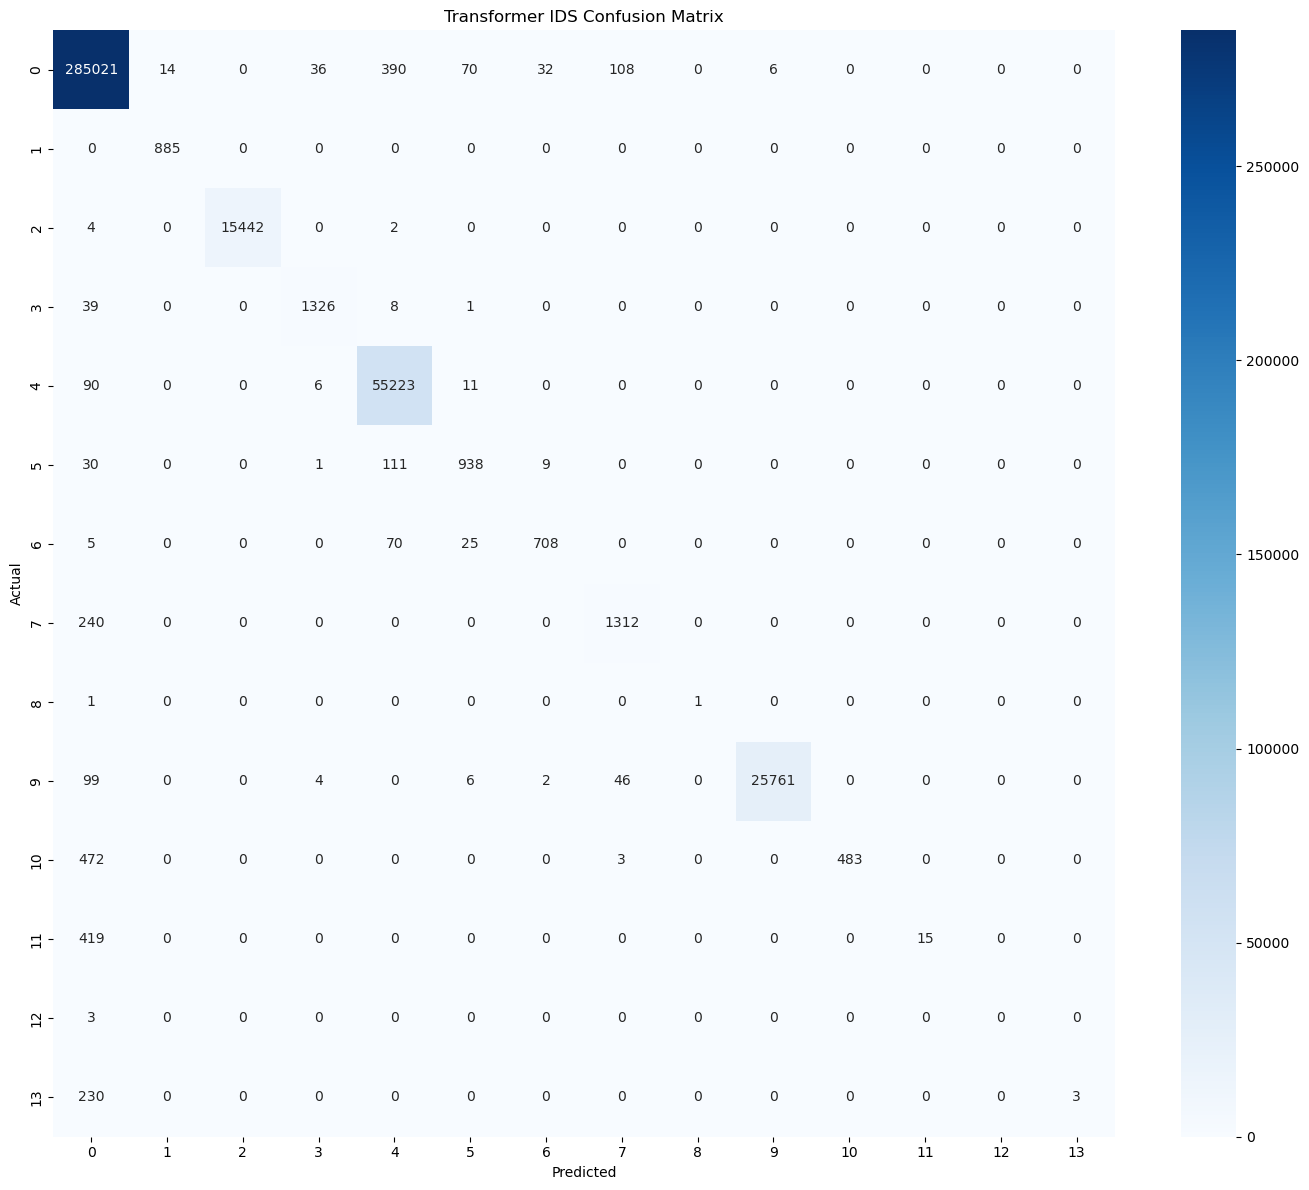

Confusion Matrix Saved


In [28]:

cm = confusion_matrix(
    y_valid_labels,
    y_pred
)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Transformer IDS Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "Confusion_Matrix.png",
    dpi=300
)

plt.show()

print("Confusion Matrix Saved")

In [ ]:
history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "training_history.csv",
    index=False
)

print("Training History Saved")

Training History Saved


In [ ]:
model.save("Transformer_IDS_Final.keras")

print("Final Model Saved Successfully")

Final Model Saved Successfully
